In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv("./data/bike_train.csv")
test = pd.read_csv("./data/bike_test.csv")

print(train.shape, test.shape)
train.info()
train.head()

(10886, 12) (6493, 9)
<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  str    
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), str(1)
memory usage: 1020.7 KB


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [ ]:
# 실기 시험에 나옴 pd.to_datetime
train["datetime"] = pd.to_datetime(train["datetime"])
test["datetime"] = pd.to_datetime(test["datetime"])

train.dtypes

datetime      datetime64[us]
season                 int64
holiday                int64
workingday             int64
weather                int64
temp                 float64
atemp                float64
humidity               int64
windspeed            float64
casual                 int64
registered             int64
count                  int64
dtype: object

In [47]:
train["year"] = train.datetime.apply(lambda x: x.year)
train["month"] = train.datetime.apply(lambda x: x.month)
train["day"] = train.datetime.apply(lambda x: x.day)
train["hour"] = train.datetime.apply(lambda x: x.hour)

test["year"] = test.datetime.apply(lambda x: x.year)
test["month"] = test.datetime.apply(lambda x: x.month)
test["day"] = test.datetime.apply(lambda x: x.day)
test["hour"] = test.datetime.apply(lambda x: x.hour)

train[["datetime", "year", "month", "day", "hour"]].head()

,datetime,year,month,day,hour
0,2011-01-01 00:00:00,2011,1,1,0
1,2011-01-01 01:00:00,2011,1,1,1
2,2011-01-01 02:00:00,2011,1,1,2
3,2011-01-01 03:00:00,2011,1,1,3
4,2011-01-01 04:00:00,2011,1,1,4


In [48]:
print(train.columns.tolist())
train.head()

['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count', 'year', 'month', 'day', 'hour']


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011,1,1,0
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011,1,1,1
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011,1,1,2
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011,1,1,3
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011,1,1,4


In [49]:
drop_cols = ["datetime", "casual", "registered"]

X_features = train.drop(["count"] + drop_cols, axis=1)
y_target = train["count"]
X_test_final = test.drop(["datetime"], axis=1)

print("X_features columns:", X_features.columns.tolist())
print("X_test_final columns:", X_test_final.columns.tolist())
X_features.head()

X_features columns: ['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'year', 'month', 'day', 'hour']
X_test_final columns: ['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'year', 'month', 'day', 'hour']


,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,year,month,day,hour
0,1,0,0,1,9.84,14.395,81,0.0,2011,1,1,0
1,1,0,0,1,9.02,13.635,80,0.0,2011,1,1,1
2,1,0,0,1,9.02,13.635,80,0.0,2011,1,1,2
3,1,0,0,1,9.84,14.395,75,0.0,2011,1,1,3
4,1,0,0,1,9.84,14.395,75,0.0,2011,1,1,4


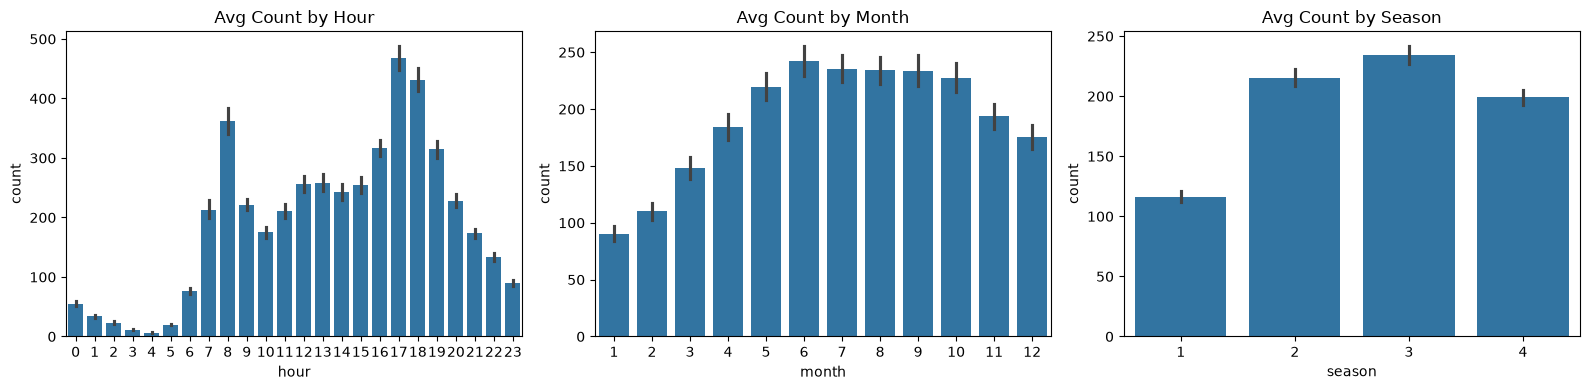

In [50]:
fig, axs = plt.subplots(figsize = (16, 4), ncols = 3)

sns.barplot(x = 'hour',
            y = 'count',
            data = train,
            ax = axs[0])
axs[0].set_title("Avg Count by Hour")

sns.barplot(x = 'month',
            y = 'count',
            data = train,
            ax = axs[1])
axs[1].set_title("Avg Count by Month")

sns.barplot(x = 'season',
            y = 'count',
            data = train,
            ax = axs[2])
axs[2].set_title("Avg Count by Season")

plt.tight_layout()
plt.show()

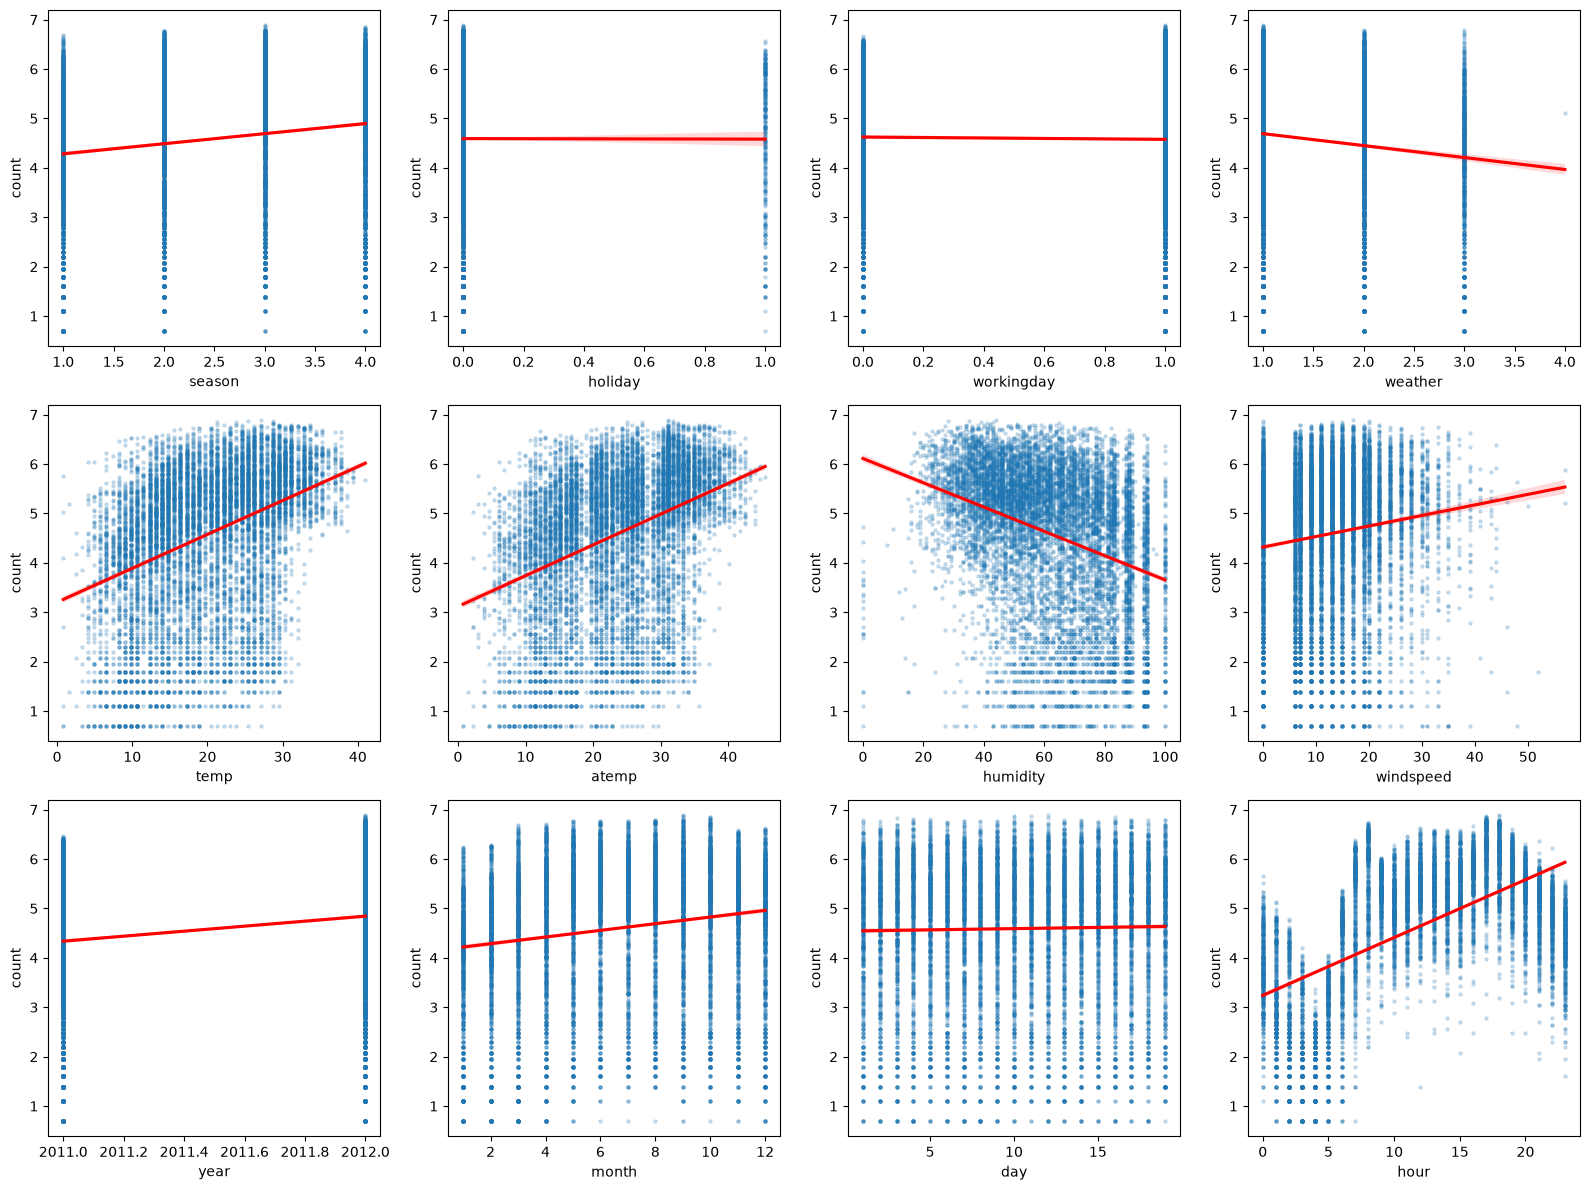

In [51]:
fig, axs = plt.subplots(figsize = (16, 12), ncols = 4, nrows = 3)

for i, feature in enumerate(X_features.columns):
    row = int(i / 4)
    col = i % 4
    sns.regplot(x = feature,
                y = np.log1p(y_target),
                data = train, 
                ax = axs[row][col],
                scatter_kws={"s": 5, "alpha": 0.2},
                line_kws={"color": "red"})

plt.tight_layout()
plt.show()

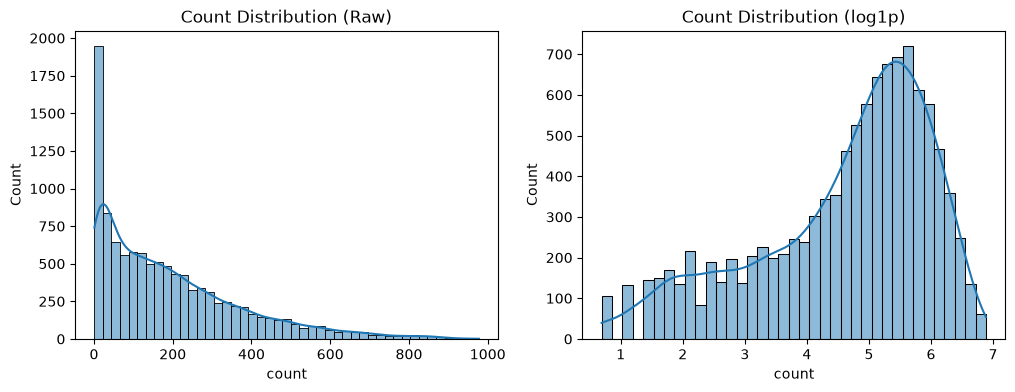

Raw count skew: 1.2420662117180776
log1p(count) skew: -0.8514116321738531


In [52]:
fig, axs = plt.subplots(figsize = (12, 4), ncols = 2)

sns.histplot(train["count"], ax=axs[0], kde=True)
axs[0].set_title("Count Distribution (Raw)")

sns.histplot(np.log1p(train["count"]), ax=axs[1], kde=True)
axs[1].set_title("Count Distribution (log1p)")

plt.show()

print("Raw count skew:", train["count"].skew())
print("log1p(count) skew:", np.log1p(train["count"]).skew())

In [53]:
y_target_log = np.log1p(y_target)

print("Original:", y_target[:5].values)
print("Log transformed:", y_target_log[:5].values)

Original: [16 40 32 13  1]
Log transformed: [2.83321334 3.71357207 3.49650756 2.63905733 0.69314718]


In [54]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def rmsle(y_true, y_pred):
    y_pred = np.clip(y_pred, a_min = 0, a_max = None)
    log_true = np.log1p(y_true)
    log_pred = np.log1p(y_pred)
    return np.sqrt(mean_squared_error(log_true, log_pred))

def evaluate_regr(y_true, y_pred):
    rmsle_val = rmsle(y_true, y_pred)
    rmse_val = np.sqrt(mean_squared_error(y_true, y_pred))
    mae_val = mean_absolute_error(y_true, y_pred)
    print(f"RMSLE: {rmsle_val:.4f}, RMSE: {rmse_val:.4f}, MAE: {mae_val:.4f}")

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train_log, y_val_log = train_test_split(X_features,
                                                          y_target_log,
                                                          test_size=0.2,
                                                          random_state=42)

print("X_train:", X_train.shape, "X_val:", X_val.shape)
print("y_train:", y_train_log.shape, "y_val:", y_val_log.shape)

X_train: (8708, 12) X_val: (2178, 12)
y_train: (8708,) y_val: (2178,)


In [56]:
from sklearn.linear_model import LinearRegression

lr_reg = LinearRegression()
lr_reg.fit(X_train, y_train_log)

pred_log = lr_reg.predict(X_val)
pred = np.expm1(pred_log)
y_val = np.expm1(y_val_log)

print("[LinearRegression]")
evaluate_regr(y_val, pred)

[LinearRegression]
RMSLE: 1.0257, RMSE: 160.6549, MAE: 108.2170


In [57]:
coeff = pd.Series(data=np.round(lr_reg.coef_, 3), index=X_features.columns)
coeff.sort_values(ascending=False)

year          0.437
hour          0.098
month         0.077
atemp         0.039
windspeed     0.004
day           0.003
temp          0.002
weather      -0.012
humidity     -0.015
season       -0.050
workingday   -0.075
holiday      -0.094
dtype: float64

In [58]:
import time
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

def get_model_cv_prediction(model, X_features, y_target_log):
    start = time.time()
    neg_mse_scores = cross_val_score(model,
                                     X_features,
                                     y_target_log,
                                     scoring = "neg_mean_squared_error",
                                     cv = 5)
    elapsed = time.time() - start
    rmse_scores = np.sqrt(-1 * neg_mse_scores)
    avg_rmse = np.mean(rmse_scores)
    print(f"{model.__class__.__name__:25s} RMSE(log) = {avg_rmse:.4f}   time = {elapsed:.1f}s")
    return model.__class__.__name__, avg_rmse, elapsed

dt_reg = DecisionTreeRegressor(random_state=42, max_depth=4)
rf_reg = RandomForestRegressor(random_state=42, n_estimators=1000, n_jobs=-1)
gb_reg = GradientBoostingRegressor(random_state=42, n_estimators=1000)
xgb_reg = XGBRegressor(n_estimators=1000, random_state=42)
lgb_reg = LGBMRegressor(n_estimators=1000, random_state=42)

models = [lr_reg, dt_reg, rf_reg, gb_reg, xgb_reg, lgb_reg]

results = []
for model in models:
    results.append(get_model_cv_prediction(model, X_features, y_target_log))

result_df = pd.DataFrame(results,
                         columns=["model", "rmse", "seconds"]).sort_values("rmse")
print("\n=== Ranking ===")
print(result_df)

LinearRegression          RMSE(log) = 1.0246   time = 0.1s
DecisionTreeRegressor     RMSE(log) = 0.7890   time = 0.1s
RandomForestRegressor     RMSE(log) = 0.4675   time = 26.4s
GradientBoostingRegressor RMSE(log) = 0.4163   time = 33.9s
XGBRegressor              RMSE(log) = 0.4442   time = 6.6s
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000177 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 286
[LightGBM] [Info] Number of data points in the train set: 8708, number of used features: 12
[LightGBM] [Info] Start training from score 4.753723
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000494 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 292
[LightGBM] [Info] Number of data points 

In [59]:
from sklearn.model_selection import GridSearchCV

gb_reg_base = GradientBoostingRegressor(random_state=42, n_estimators=1000)

# 3-fold 교차검증
params = {"learning_rate": [0.02, 0.05, 0.1],
          "max_depth": [3, 4, 5],
          "min_samples_leaf": [1, 2, 3],
          "subsample": [0.8, 0.9, 1.0]}

grid_reg = GridSearchCV(gb_reg_base,
                        param_grid=params,
                        scoring="neg_mean_squared_error",
                        cv = 3,
                        n_jobs = -1)

start = time.time()
grid_reg.fit(X_train, y_train_log)
print(f"Tuning time: {time.time()-start:.1f}s")

print("Best params:", grid_reg.best_params_)
print("Best RMSE(log):", np.sqrt(-grid_reg.best_score_))

best_model = grid_reg.best_estimator_

Tuning time: 232.3s
Best params: {'learning_rate': 0.02, 'max_depth': 5, 'min_samples_leaf': 3, 'subsample': 0.8}
Best RMSE(log): 0.30319946485138777


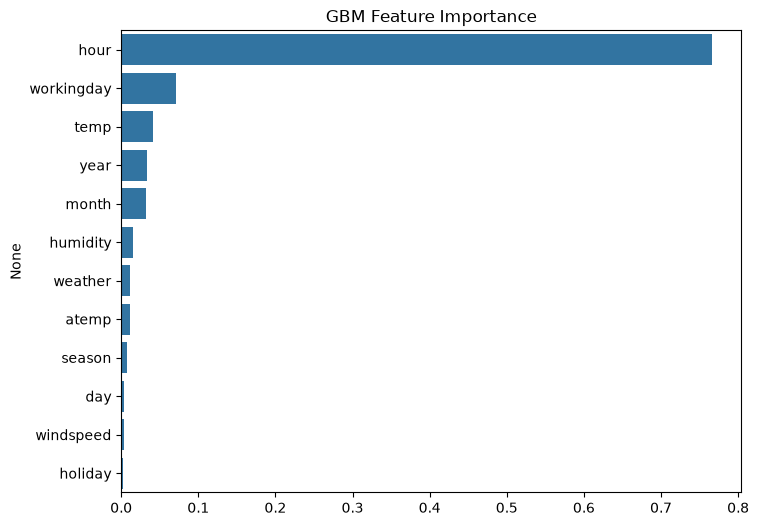

hour          0.765632
workingday    0.070877
temp          0.041781
year          0.033550
month         0.032097
humidity      0.015829
weather       0.011329
atemp         0.011257
season        0.007923
day           0.004272
windspeed     0.003269
holiday       0.002184
dtype: float64


In [60]:
best_model.fit(X_features, y_target_log)

feature_series = pd.Series(best_model.feature_importances_, index = X_features.columns)
feature_series = feature_series.sort_values(ascending = False)

plt.figure(figsize = (8, 6))
sns.barplot(x = feature_series.values, y = feature_series.index)
plt.title("GBM Feature Importance")
plt.show()

print(feature_series)

[Tuned GradientBoosting]
RMSLE: 0.2997, RMSE: 41.5277, MAE: 26.0413
R2: 0.9477519444887538

[Baseline: LinearRegression]
RMSLE: 1.0257, RMSE: 160.6549, MAE: 108.2170


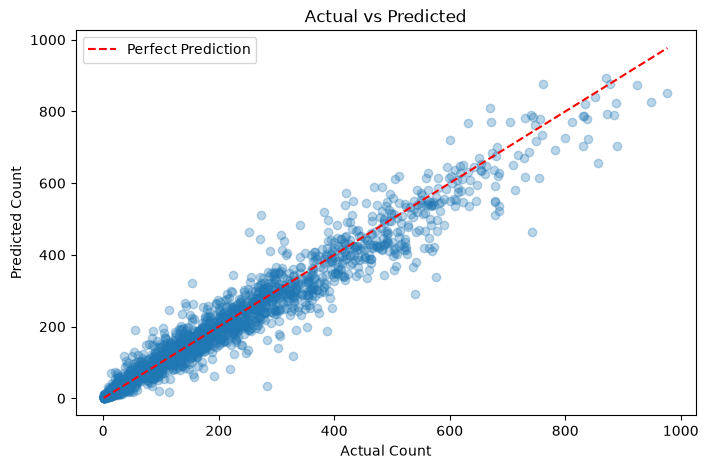

In [61]:
from sklearn.metrics import r2_score

best_model.fit(X_train, y_train_log)
pred_log_best = best_model.predict(X_val)
pred_best = np.expm1(pred_log_best)

print("[Tuned GradientBoosting]")
evaluate_regr(y_val, pred_best)
print("R2:", r2_score(y_val, pred_best))

print("\n[Baseline: LinearRegression]")
evaluate_regr(y_val, pred)

plt.figure(figsize=(8, 5))
plt.scatter(y_val, pred_best, alpha=0.3)
plt.plot([y_val.min(), y_val.max()],
         [y_val.min(), y_val.max()],
         "r--",
         label="Perfect Prediction")
plt.xlabel("Actual Count")
plt.ylabel("Predicted Count")
plt.title("Actual vs Predicted")
plt.legend()
plt.show()

In [62]:
final_model = grid_reg.best_estimator_
final_model.fit(X_features, y_target_log)

final_pred_log = final_model.predict(X_test_final)
final_pred = np.expm1(final_pred_log)
final_pred = np.clip(final_pred, a_min = 0, a_max = None)

final = pd.DataFrame({
    "datetime": test["datetime"],
    "count": final_pred
})

print(final.shape)
final.head()


(6493, 2)


,datetime,count
0,2011-01-20 00:00:00,8.213999
1,2011-01-20 01:00:00,4.693359
2,2011-01-20 02:00:00,2.746349
3,2011-01-20 03:00:00,1.657035
4,2011-01-20 04:00:00,1.628936
